In [1]:
# importing relevant libraries
import pandas as pd
import numpy as np
import json
import os
from itertools import chain

# import boto3

from tqdm.notebook import tqdm_notebook
import time

import csv
import re

# display all rows & columns
#pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

# show all outputs
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'

# Disable warnings
import warnings
warnings.filterwarnings("ignore")

**Import data for analysis**

In [2]:
# Import data
attrition_list = 'Hopeliner Copy of Sample 2022 Attrition List.xlsx'
responses = 'TTEC Interviews (Responses).xlsx'

attrition_df = pd.read_excel(attrition_list)
response_df = pd.read_excel(responses)

# Strip column names
attrition_df.columns = [x.strip() for x in attrition_df.columns]
response_df.columns = [x.strip() for x in response_df.columns]

# Response df - pre-processing
response_df.rename(columns =  {'Read Call Opening: \nHi (First Name), thank you for making time for this short interview or chat with us. As shared in our (email/ SMS) exchange, my name is (Interviewer Name). I am from e-BI Solutions. We are working with TTEC to find ways to improve their employee experience so we are grateful that you made time for this.':'Read Call Opening',
                              'Confidentiality Notice and Consent:\nPlease note that we will treat our conversation with confidentiality and only disclose information to the extent you wish to share them with TTEC. Our goal is to help them improve the employee experience through an unbiased study and analysis of the data we gather. We will ask for your sign-off on the final notes we will include in the study. Do you agree and consent to this interview/ short chat? (Share option to record video/ audio/ transcript only)\n\n(Wait for response. Proceed with questions as appropriate)': 'Confidentiality Notice and Consent',
                              }, inplace = True)

cols = ['Stated Reason for Leaving TTEC', 'Other considerations for leaving', 'Top 3 Low lights and impact to them',
'Highlights of their stay with TTEC', 'Suggestions on redesigning the experience',
'What would make you consider returning or referring friends and family members to TTEC?',
'Any questions for e-BI or TTEC?']

for col in cols:
    response_df[col] = response_df[col].astype(str)

## Pre-processing Descriptive Data

In [3]:
# pip install gensim
# pip install nltk
# pip install matplotlib
# pip install advertools
# Run 'python -m nltk.downloader all' on ubuntu
# pip install typing-extensions --upgrade

In [4]:
#import modules
import nltk
import gensim
import advertools as adv
import matplotlib.pyplot
import os.path
from gensim import corpora
from gensim.models import LsiModel
from nltk.tokenize import RegexpTokenizer
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from gensim.models.coherencemodel import CoherenceModel
import matplotlib.pyplot as plt

**Functions**

> 1) Tokenizing, removing stop words, stemming

In [5]:
def preprocess_data(doc_set):
    """
    Input  : docuemnt list
    Purpose: preprocess text (tokenize, removing stopwords, and stemming)
    Output : preprocessed text
    """
    # initialize regex tokenizer
    tokenizer = RegexpTokenizer(r'\w+')
    # create English stop words list
    en_stop = set(stopwords.words('english'))
    # Create p_stemmer of class PorterStemmer
    p_stemmer = PorterStemmer()
    # list for tokenized documents in loop
    texts = []

    # clean and tokenize document string
    raw = doc_set.lower()
    tokens = tokenizer.tokenize(raw)
    # remove stop words from tokens
    stopped_tokens = [i for i in tokens if not i in en_stop]
    # stem tokens
    stemmed_tokens = [p_stemmer.stem(i) for i in stopped_tokens]
    # add tokens to list
    texts.append(stemmed_tokens)
    
    return texts

In [28]:
def preprocess_data_indiv(doc_set):
    """
    Input  : docuemnt list
    Purpose: preprocess text (tokenize, removing stopwords, and stemming)
    Output : preprocessed text
    """
    # initialize regex tokenizer
    tokenizer = RegexpTokenizer(r'\w+')
    # create English & Tagalog stop words list
    en_stop = set(stopwords.words('english') + list(adv.stopwords['tagalog']))
    # Create p_stemmer of class PorterStemmer
    p_stemmer = PorterStemmer()
    # list for tokenized documents in loop
    texts = []
    # loop through document list
    for i in doc_set:
        # clean and tokenize document string
        raw = i.lower()
        tokens = tokenizer.tokenize(raw)
        # remove stop words from tokens
        stopped_tokens = [i for i in tokens if not i in en_stop]
        # stem tokens
        stemmed_tokens = [p_stemmer.stem(i) for i in stopped_tokens]
        # add tokens to list
        texts.append(stemmed_tokens)
    return texts

In [29]:
# Text response fields (all responses combined) from response_df
field_text = dict()
indiv_responses = dict()

field_name = ['Reason for Leaving', 'Leaving Considerations', 'Low Lights and Impact', 'Highlights of Stay', 'Improvements Suggestions', 'Return Considerations', 'Questions']
cols = ['Stated Reason for Leaving TTEC', 'Other considerations for leaving', 'Top 3 Low lights and impact to them',
       'Highlights of their stay with TTEC', 'Suggestions on redesigning the experience',
       'What would make you consider returning or referring friends and family members to TTEC?',
       'Any questions for e-BI or TTEC?']

for i in range(0, len(field_name)):
    field_text[field_name[i]] = ' '.join(response_df[cols[i]].to_list())
    indiv_responses[field_name[i]] = response_df[cols[i]].to_list()
    

In [30]:
# Pre-processing combined text per field (Tokenizing, remove stop words, stemming)
clean_docs = dict()
clean_indiv_responses = dict()

for field in list(field_text.keys()):
    clean_docs[field] = preprocess_data(doc_set = field_text[field])[0]
    clean_indiv_responses[field] = preprocess_data_indiv(indiv_responses[field])

> 2) Preparing corpus & LSA model using Gensim

In [31]:
def prepare_corpus(doc_clean):
    """
    Input  : clean document
    Purpose: create term dictionary of our courpus and Converting list of documents (corpus) into Document Term Matrix
    Output : term dictionary and Document Term Matrix
    """
    # Creating the term dictionary of our courpus, where every unique term is assigned an index. dictionary = corpora.Dictionary(doc_clean)
    dictionary = corpora.Dictionary(doc_clean)
    # Converting list of documents (corpus) into Document Term Matrix using dictionary prepared above.
    doc_term_matrix = [dictionary.doc2bow(doc) for doc in doc_clean]
    # generate LDA model
    return dictionary,doc_term_matrix


In [32]:
def create_gensim_lsa_model(doc_clean,number_of_topics,words): 
    """
    Input  : clean document, number of topics and number of words associated with each topic
    Purpose: create LSA model using gensim
    Output : return LSA model
    """
    dictionary,doc_term_matrix=prepare_corpus(doc_clean)
    # generate LSA model
    lsamodel = LsiModel(doc_term_matrix, num_topics=number_of_topics, id2word = dictionary)  # train model
    topics = lsamodel.print_topics(num_topics=number_of_topics, num_words=words)
    return lsamodel, topics

In [33]:
def compute_coherence_values(dictionary, doc_term_matrix, doc_clean, stop, start=2, step=3):
    """
    Input   : dictionary : Gensim dictionary
              corpus : Gensim corpus
              texts : List of input texts
              stop : Max num of topics
    purpose : Compute c_v coherence for various number of topics
    Output  : model_list : List of LSA topic models
              coherence_values : Coherence values corresponding to the LDA model with respective number of topics
    """
    coherence_values = []
    model_list = []
    for num_topics in range(start, stop, step):
        # generate LSA model
        model = LsiModel(doc_term_matrix, num_topics=number_of_topics, id2word = dictionary)  # train model
        model_list.append(model)
        coherencemodel = CoherenceModel(model=model, texts=doc_clean, dictionary=dictionary, coherence='c_v')
        coherence_values.append(coherencemodel.get_coherence())
    return model_list, coherence_values

In [34]:
def plot_graph(doc_clean,start, stop, step):
    dictionary,doc_term_matrix=prepare_corpus(doc_clean)
    model_list, coherence_values = compute_coherence_values(dictionary, doc_term_matrix,doc_clean,
                                                            stop, start, step)
    # Show graph
    x = range(start, stop, step)
    plt.plot(x, coherence_values)
    plt.xlabel("Number of Topics")
    plt.ylabel("Coherence score")
    plt.legend(("coherence_values"), loc='best')
    plt.show()


In [44]:
clean_docs['Reason for Leaving']

['diagnos',
 'depress',
 'anxieti',
 'person',
 'reason',
 'still',
 'want',
 'go',
 'back',
 'futur',
 'immedi',
 'resign',
 'due',
 'stress',
 'work',
 'affect',
 'auto',
 'immun',
 'diseas',
 'famili',
 'reason',
 'need',
 'choos',
 'famili',
 'work',
 'sinc',
 'slowli',
 'go',
 'back',
 'offic',
 'travel',
 'far',
 'spend',
 'time',
 'work',
 'sa',
 'offic',
 'decid',
 'give',
 'ttec',
 'even',
 'work',
 'agent',
 '4',
 'year',
 'famili',
 'problem',
 'forc',
 'resign',
 'health',
 'issu',
 'incid',
 'tri',
 'appli',
 'compani',
 'need',
 'make',
 'choic',
 'alreadi',
 'decid',
 'whether',
 'resign',
 'ttec',
 'suddenli',
 'experienc',
 'famili',
 'problem',
 'specif',
 'kid',
 'dahil',
 'walang',
 'mag',
 'aalaga',
 'prepar',
 'board',
 'exam',
 'alreadi',
 'plan',
 'resign',
 'person',
 'growth',
 'decid',
 'leav',
 'ttec',
 'call',
 'center',
 'field',
 'fulli',
 'decid',
 'leav',
 'ttec',
 'due',
 'toxic',
 'trait',
 'individu',
 'ttec',
 'person',
 'reason',
 'disclos',
 'ex',

In [42]:
clean_indiv_responses['Reason for Leaving']

[['diagnos', 'depress', 'anxieti'],
 ['person', 'reason', 'still', 'want', 'go', 'back', 'futur'],
 ['immedi',
  'resign',
  'due',
  'stress',
  'work',
  'affect',
  'auto',
  'immun',
  'diseas'],
 ['famili',
  'reason',
  'need',
  'choos',
  'famili',
  'work',
  'sinc',
  'slowli',
  'go',
  'back',
  'offic',
  'travel',
  'far',
  'spend',
  'time',
  'work',
  'offic',
  'decid',
  'give',
  'ttec',
  'even',
  'work',
  'agent',
  '4',
  'year'],
 ['famili',
  'problem',
  'forc',
  'resign',
  'health',
  'issu',
  'incid',
  'tri',
  'appli',
  'compani'],
 ['need',
  'make',
  'choic',
  'alreadi',
  'decid',
  'whether',
  'resign',
  'ttec',
  'suddenli',
  'experienc',
  'famili',
  'problem',
  'specif',
  'kid',
  'mag',
  'aalaga'],
 ['prepar', 'board', 'exam'],
 ['alreadi',
  'plan',
  'resign',
  'person',
  'growth',
  'decid',
  'leav',
  'ttec',
  'call',
  'center',
  'field',
  'fulli',
  'decid',
  'leav',
  'ttec',
  'due',
  'toxic',
  'trait',
  'individu'

In [46]:
# Inputs
doc_clean = clean_indiv_responses['Reason for Leaving']
dictionary, doc_term_matrix = prepare_corpus(doc_clean)
stop = 12 # max. no. of topics
number_of_topics = 12

2022-12-15 17:18:58,075 | INFO | dictionary.py:209 | add_documents | adding document #0 to Dictionary(0 unique tokens: [])
2022-12-15 17:18:58,080 | INFO | dictionary.py:214 | add_documents | built Dictionary(362 unique tokens: ['anxieti', 'depress', 'diagnos', 'back', 'futur']...) from 82 documents (total 768 corpus positions)


2022-12-15 16:56:54,319 | INFO | dictionary.py:209 | add_documents | adding document #0 to Dictionary(0 unique tokens: [])
2022-12-15 16:56:54,322 | INFO | dictionary.py:214 | add_documents | built Dictionary(362 unique tokens: ['anxieti', 'depress', 'diagnos', 'back', 'futur']...) from 82 documents (total 768 corpus positions)
2022-12-15 16:56:54,323 | INFO | lsimodel.py:420 | __init__ | using serial LSI version on this node
2022-12-15 16:56:54,324 | INFO | lsimodel.py:466 | add_documents | updating model with new documents
2022-12-15 16:56:54,325 | INFO | lsimodel.py:492 | add_documents | preparing a new chunk of documents
2022-12-15 16:56:54,326 | INFO | lsimodel.py:912 | stochastic_svd | using 100 extra samples and 2 power iterations
2022-12-15 16:56:54,327 | INFO | lsimodel.py:920 | stochastic_svd | 1st phase: constructing (362, 112) action matrix
2022-12-15 16:56:54,328 | INFO | lsimodel.py:935 | stochastic_svd | orthonormalizing (362, 112) action matrix
2022-12-15 16:56:54,339 |

2022-12-15 16:56:58,956 | INFO | probability_estimation.py:155 | p_boolean_sliding_window | using ParallelWordOccurrenceAccumulator(processes=7, batch_size=64) to estimate probabilities from sliding windows
2022-12-15 16:57:00,771 | INFO | text_analysis.py:530 | terminate_workers | 7 accumulators retrieved from output queue
2022-12-15 16:57:00,811 | INFO | text_analysis.py:552 | merge_accumulators | accumulated word occurrence stats for 73 virtual documents
2022-12-15 16:57:01,215 | INFO | lsimodel.py:420 | __init__ | using serial LSI version on this node
2022-12-15 16:57:01,215 | INFO | lsimodel.py:466 | add_documents | updating model with new documents
2022-12-15 16:57:01,216 | INFO | lsimodel.py:492 | add_documents | preparing a new chunk of documents
2022-12-15 16:57:01,218 | INFO | lsimodel.py:912 | stochastic_svd | using 100 extra samples and 2 power iterations
2022-12-15 16:57:01,219 | INFO | lsimodel.py:920 | stochastic_svd | 1st phase: constructing (362, 112) action matrix
202

2022-12-15 16:57:06,899 | INFO | probability_estimation.py:155 | p_boolean_sliding_window | using ParallelWordOccurrenceAccumulator(processes=7, batch_size=64) to estimate probabilities from sliding windows
2022-12-15 16:57:10,513 | INFO | text_analysis.py:530 | terminate_workers | 7 accumulators retrieved from output queue
2022-12-15 16:57:10,550 | INFO | text_analysis.py:552 | merge_accumulators | accumulated word occurrence stats for 82 virtual documents
2022-12-15 16:57:10,999 | INFO | lsimodel.py:420 | __init__ | using serial LSI version on this node
2022-12-15 16:57:10,999 | INFO | lsimodel.py:466 | add_documents | updating model with new documents
2022-12-15 16:57:11,000 | INFO | lsimodel.py:492 | add_documents | preparing a new chunk of documents
2022-12-15 16:57:11,001 | INFO | lsimodel.py:912 | stochastic_svd | using 100 extra samples and 2 power iterations
2022-12-15 16:57:11,002 | INFO | lsimodel.py:920 | stochastic_svd | 1st phase: constructing (362, 112) action matrix
202

2022-12-15 16:57:16,227 | INFO | probability_estimation.py:155 | p_boolean_sliding_window | using ParallelWordOccurrenceAccumulator(processes=7, batch_size=64) to estimate probabilities from sliding windows
2022-12-15 16:57:18,171 | INFO | text_analysis.py:530 | terminate_workers | 7 accumulators retrieved from output queue
2022-12-15 16:57:18,205 | INFO | text_analysis.py:552 | merge_accumulators | accumulated word occurrence stats for 82 virtual documents
2022-12-15 16:57:18,666 | INFO | lsimodel.py:420 | __init__ | using serial LSI version on this node
2022-12-15 16:57:18,667 | INFO | lsimodel.py:466 | add_documents | updating model with new documents
2022-12-15 16:57:18,668 | INFO | lsimodel.py:492 | add_documents | preparing a new chunk of documents
2022-12-15 16:57:18,669 | INFO | lsimodel.py:912 | stochastic_svd | using 100 extra samples and 2 power iterations
2022-12-15 16:57:18,670 | INFO | lsimodel.py:920 | stochastic_svd | 1st phase: constructing (362, 112) action matrix
202

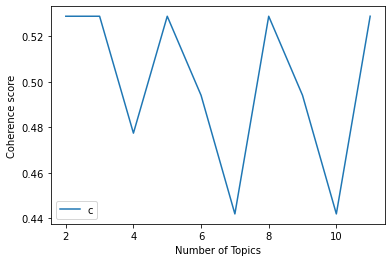

In [36]:
start,stop,step=2,12,1
plot_graph(doc_clean,start,stop,step)

In [21]:
# LSA Model
number_of_topics=7
words=10
model = create_gensim_lsa_model(doc_clean=doc_clean,number_of_topics=number_of_topics,words=words)

2022-12-15 16:54:51,679 | INFO | dictionary.py:209 | add_documents | adding document #0 to Dictionary(0 unique tokens: [])
2022-12-15 16:54:51,683 | INFO | dictionary.py:214 | add_documents | built Dictionary(375 unique tokens: ['anxieti', 'depress', 'diagnos', 'back', 'futur']...) from 82 documents (total 796 corpus positions)
2022-12-15 16:54:51,686 | INFO | lsimodel.py:420 | __init__ | using serial LSI version on this node
2022-12-15 16:54:51,687 | INFO | lsimodel.py:466 | add_documents | updating model with new documents
2022-12-15 16:54:51,689 | INFO | lsimodel.py:492 | add_documents | preparing a new chunk of documents
2022-12-15 16:54:51,692 | INFO | lsimodel.py:912 | stochastic_svd | using 100 extra samples and 2 power iterations
2022-12-15 16:54:51,693 | INFO | lsimodel.py:920 | stochastic_svd | 1st phase: constructing (375, 107) action matrix
2022-12-15 16:54:51,697 | INFO | lsimodel.py:935 | stochastic_svd | orthonormalizing (375, 107) action matrix
2022-12-15 16:54:51,719 |

In [43]:
topics = model[1]
topics


[(0,
  '0.429*"work" + 0.285*"time" + 0.234*"go" + 0.210*"account" + 0.206*"decid" + 0.179*"employe" + 0.157*"sinc" + 0.157*"supervisor" + 0.154*"ask" + 0.131*"leav"'),
 (1,
  '0.385*"supervisor" + -0.314*"time" + -0.236*"leav" + 0.225*"account" + 0.192*"difficulti" + 0.192*"custom" + 0.191*"support" + 0.172*"especi" + 0.163*"ask" + -0.162*"decid"'),
 (2,
  '-0.337*"trainer" + -0.240*"train" + 0.230*"work" + -0.223*"ask" + -0.200*"next" + 0.157*"go" + -0.152*"resign" + 0.146*"employe" + 0.142*"wfh" + -0.136*"siya"'),
 (3,
  '-0.401*"employe" + 0.269*"time" + -0.261*"work" + 0.209*"leav" + 0.174*"supervisor" + -0.172*"sa" + -0.172*"train" + 0.151*"sinc" + -0.145*"former" + 0.139*"especi"'),
 (4,
  '-0.334*"employe" + 0.279*"work" + -0.242*"leav" + 0.189*"wfh" + -0.170*"time" + -0.165*"former" + -0.163*"enough" + -0.163*"supervisor" + 0.150*"famili" + -0.131*"ang"'),
 (5,
  '-0.287*"person" + -0.239*"pay" + -0.230*"reason" + -0.202*"salari" + 0.188*"wfh" + 0.186*"former" + -0.184*"ttec" 